# Summary figures

In [1]:
# import
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
import pandas as pd
import os
import sys
import MDAnalysis as mda
import numpy as np

## Figure 5: ligand binding times

In [2]:
# dataframe 
# create dataframe
sims = (1,1,1,2,2,2,3,3,3,4,4,4,5,5,5,6,6,6)  # 3 replica for each ligand
dc_bound = (65,11,50,34,60,15,54,32,30,10,3,92,18,34,12,2,87,7)  # ligand unbound from DC-SIGN
mrc_bound = (219,73,39,84,19,33,139,500,190,193,63,71,500,23,13,22,323,31)  # ligand unbound from MRC1

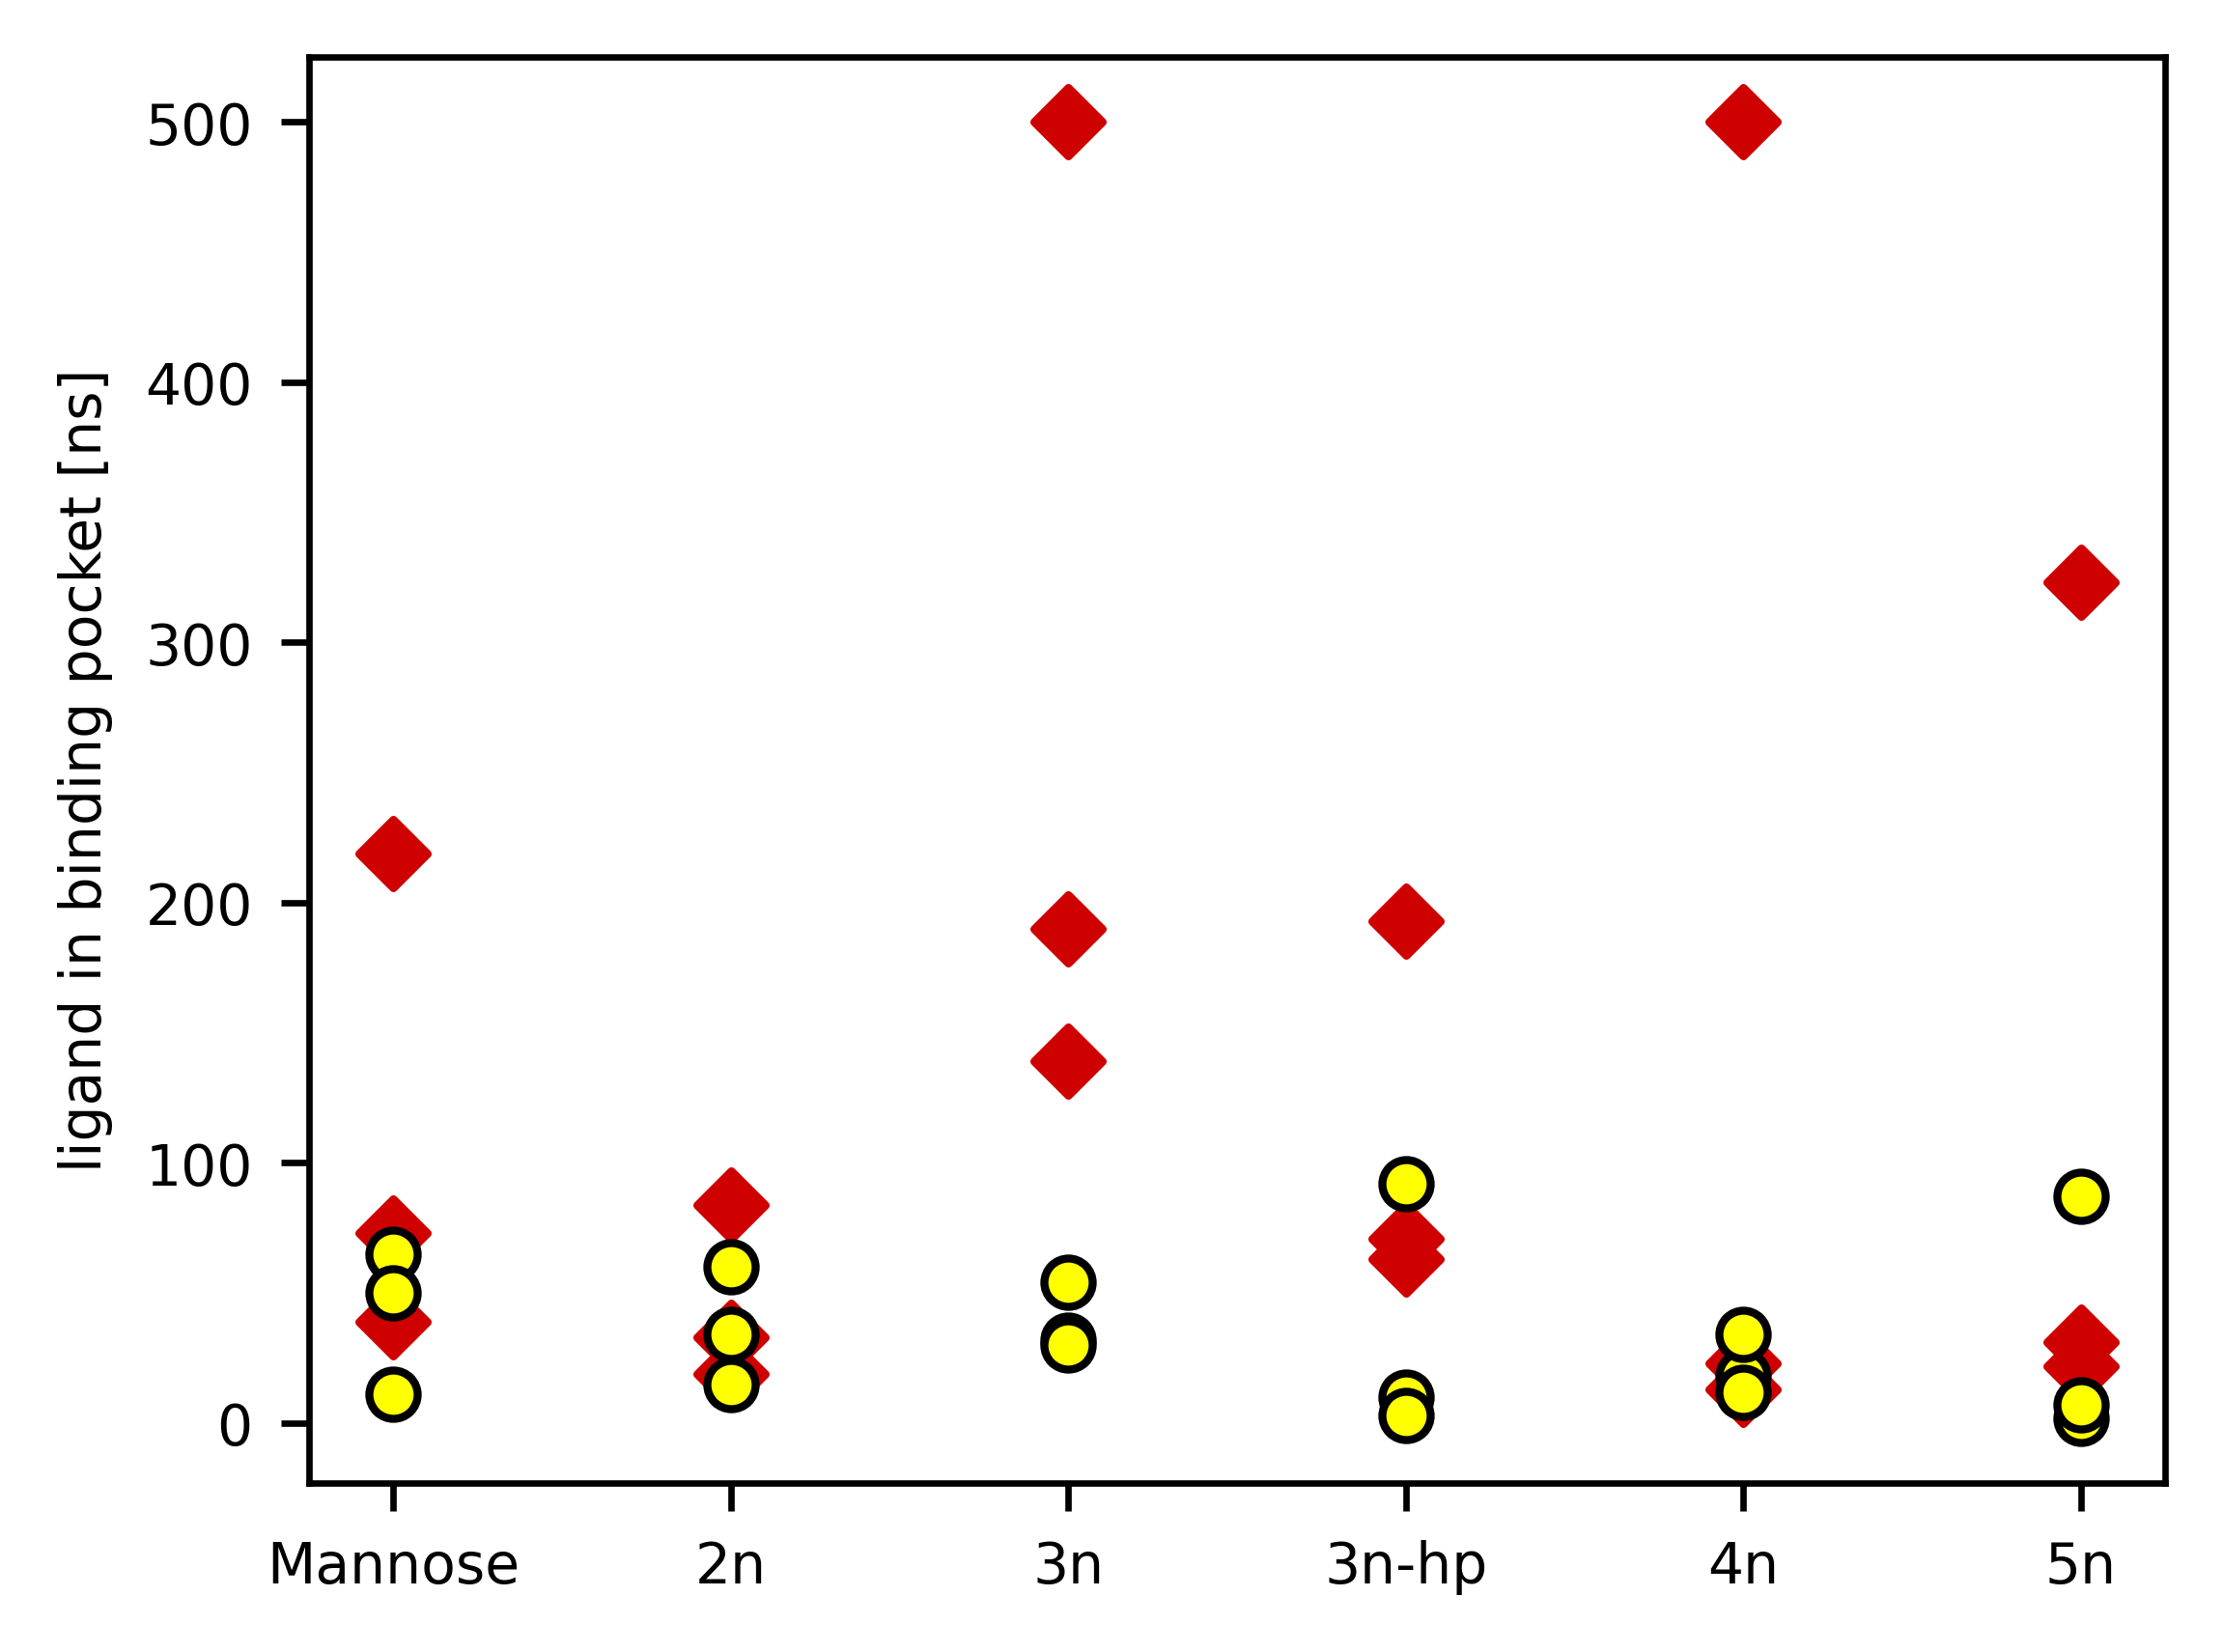

In [4]:
cm = 1/2.54
fig, ax = plt.subplots(figsize=(10*cm, 7.5*cm), dpi=600)

ax.scatter(sims, mrc_bound, marker='D', c='#CF0000', 
           # edgecolors='grey'
          )  # plot MRC datapoints as red diamonds
ax.scatter(sims, dc_bound, c='#FFFF00', edgecolors='black')  # plot DC datapoints as yellow circles
plt.xticks([1, 2, 3, 4, 5, 6], ['Mannose', '2n', '3n', '3n-hp', '4n', '5n'], fontsize=7)
plt.yticks(fontsize=7)
ax.set_ylabel('ligand in binding pocket [ns]', fontsize=7)
plt.tight_layout()

## Figure 7a) barplot with different states

This is an overviwe figure of how many frames were in each state for each simulation (while the ligand was bound to its respective receptor). The calculations were done separately in the analysis notebook of each simulation.

In [20]:
### dataframe: how many frames in each state for each simulation

colors = ["#1F77B4", "#2CA02C", "#FF7F0B", "#D62728", "#9467BD"]  # colors for different states
# DC-SIGN simulations
dc=pd.DataFrame([[96,63,323,0,781], # man
    [324, 369, 124, 0, 276],  # 2n
    [553, 90, 115, 0, 405],  # 3n
    [93, 819, 0, 0, 141],  # 3nhp
    [261, 103, 79, 0, 103],  # 4n
    [273, 450, 31, 0, 209]],  # 5n
               index=["man", "2n", "3n", "3nhp","4n","5n"],  # ligand in that simulation
                   columns=["crystal", "A", "B", "C", "other"]  # states
               )  
# MRC1 simulations
mrc=pd.DataFrame([[932, 281, 430,1247, 423],  # man
    [1025, 79, 141, 0, 118],  # 2n
    [3101, 1, 421, 4212, 558],  # 3n
    [2220, 364, 457, 0, 232],  # 3nhp
    [453, 0, 124, 4157, 629],  # 4n
    [3241, 1, 387, 0, 134]],  # 5n
               index=["man", "2n", "3n", "3nhp","4n","5n"],
                   columns=["crystal", "A", "B", "C", "other"]
                ) 

In [51]:
# code to produce the grouped & stacked barplot

import pandas as pd
import matplotlib.cm as cm
import numpy as np
import matplotlib.pyplot as plt

def plot_clustered_stacked_horizontal(dfall, labels=None, title="",  H="/", **kwargs):
    """Given a list of dataframes, with identical columns and index, create a clustered stacked bar plot with horizontal bars. 
    labels is a list of the names of the dataframe, used for the legend
    title is a string for the title of the plot
    H is the hatch used for identification of the different dataframe"""

    n_df = len(dfall)
    n_col = len(dfall[0].columns) 
    n_ind = len(dfall[0].index)
    axe = plt.subplot(111)

    for df in dfall:  # for each data frame
        axe = df.plot(kind="barh",  # Change to horizontal bars
                      linewidth=0,
                      stacked=True,
                      ax=axe,
                      legend=False,
                      grid=False,
                      color=colors,   # <-- HERE COLORS
                      **kwargs)  # make bar plots

    h, l = axe.get_legend_handles_labels()  # get the handles we want to modify
    for i in range(0, n_df * n_col, n_col):  # len(h) = n_col * n_df
        for j, pa in enumerate(h[i:i+n_col]):
            for rect in pa.patches:  # for each index
                rect.set_y(rect.get_y() + 1 / float(n_df + 1) * i / float(n_col))
                rect.set_hatch(H * int(i / n_col))  # modified part     
                rect.set_height(1 / float(n_df + 1))

    axe.set_yticks((np.arange(0, 2 * n_ind, 2) + 1 / float(n_df + 1)) / 2.)  # adjust y-ticks for horizontal bars
    axe.set_yticklabels(dfall[0].index, rotation=0)  # adjust y-labels for horizontal bars
    axe.set_title(title)

    # Reverse the y-axis
    axe.invert_yaxis()

    # Add invisible data to add another legend
    n=[]        
    for i in range(n_df):
        n.append(axe.barh(0, 0, color="gray", hatch=H if i == 0 else ""))

    if labels is not None:
        axe.legend(n[::-1], labels[::-1], loc="upper right", title="Receptor")
    return axe

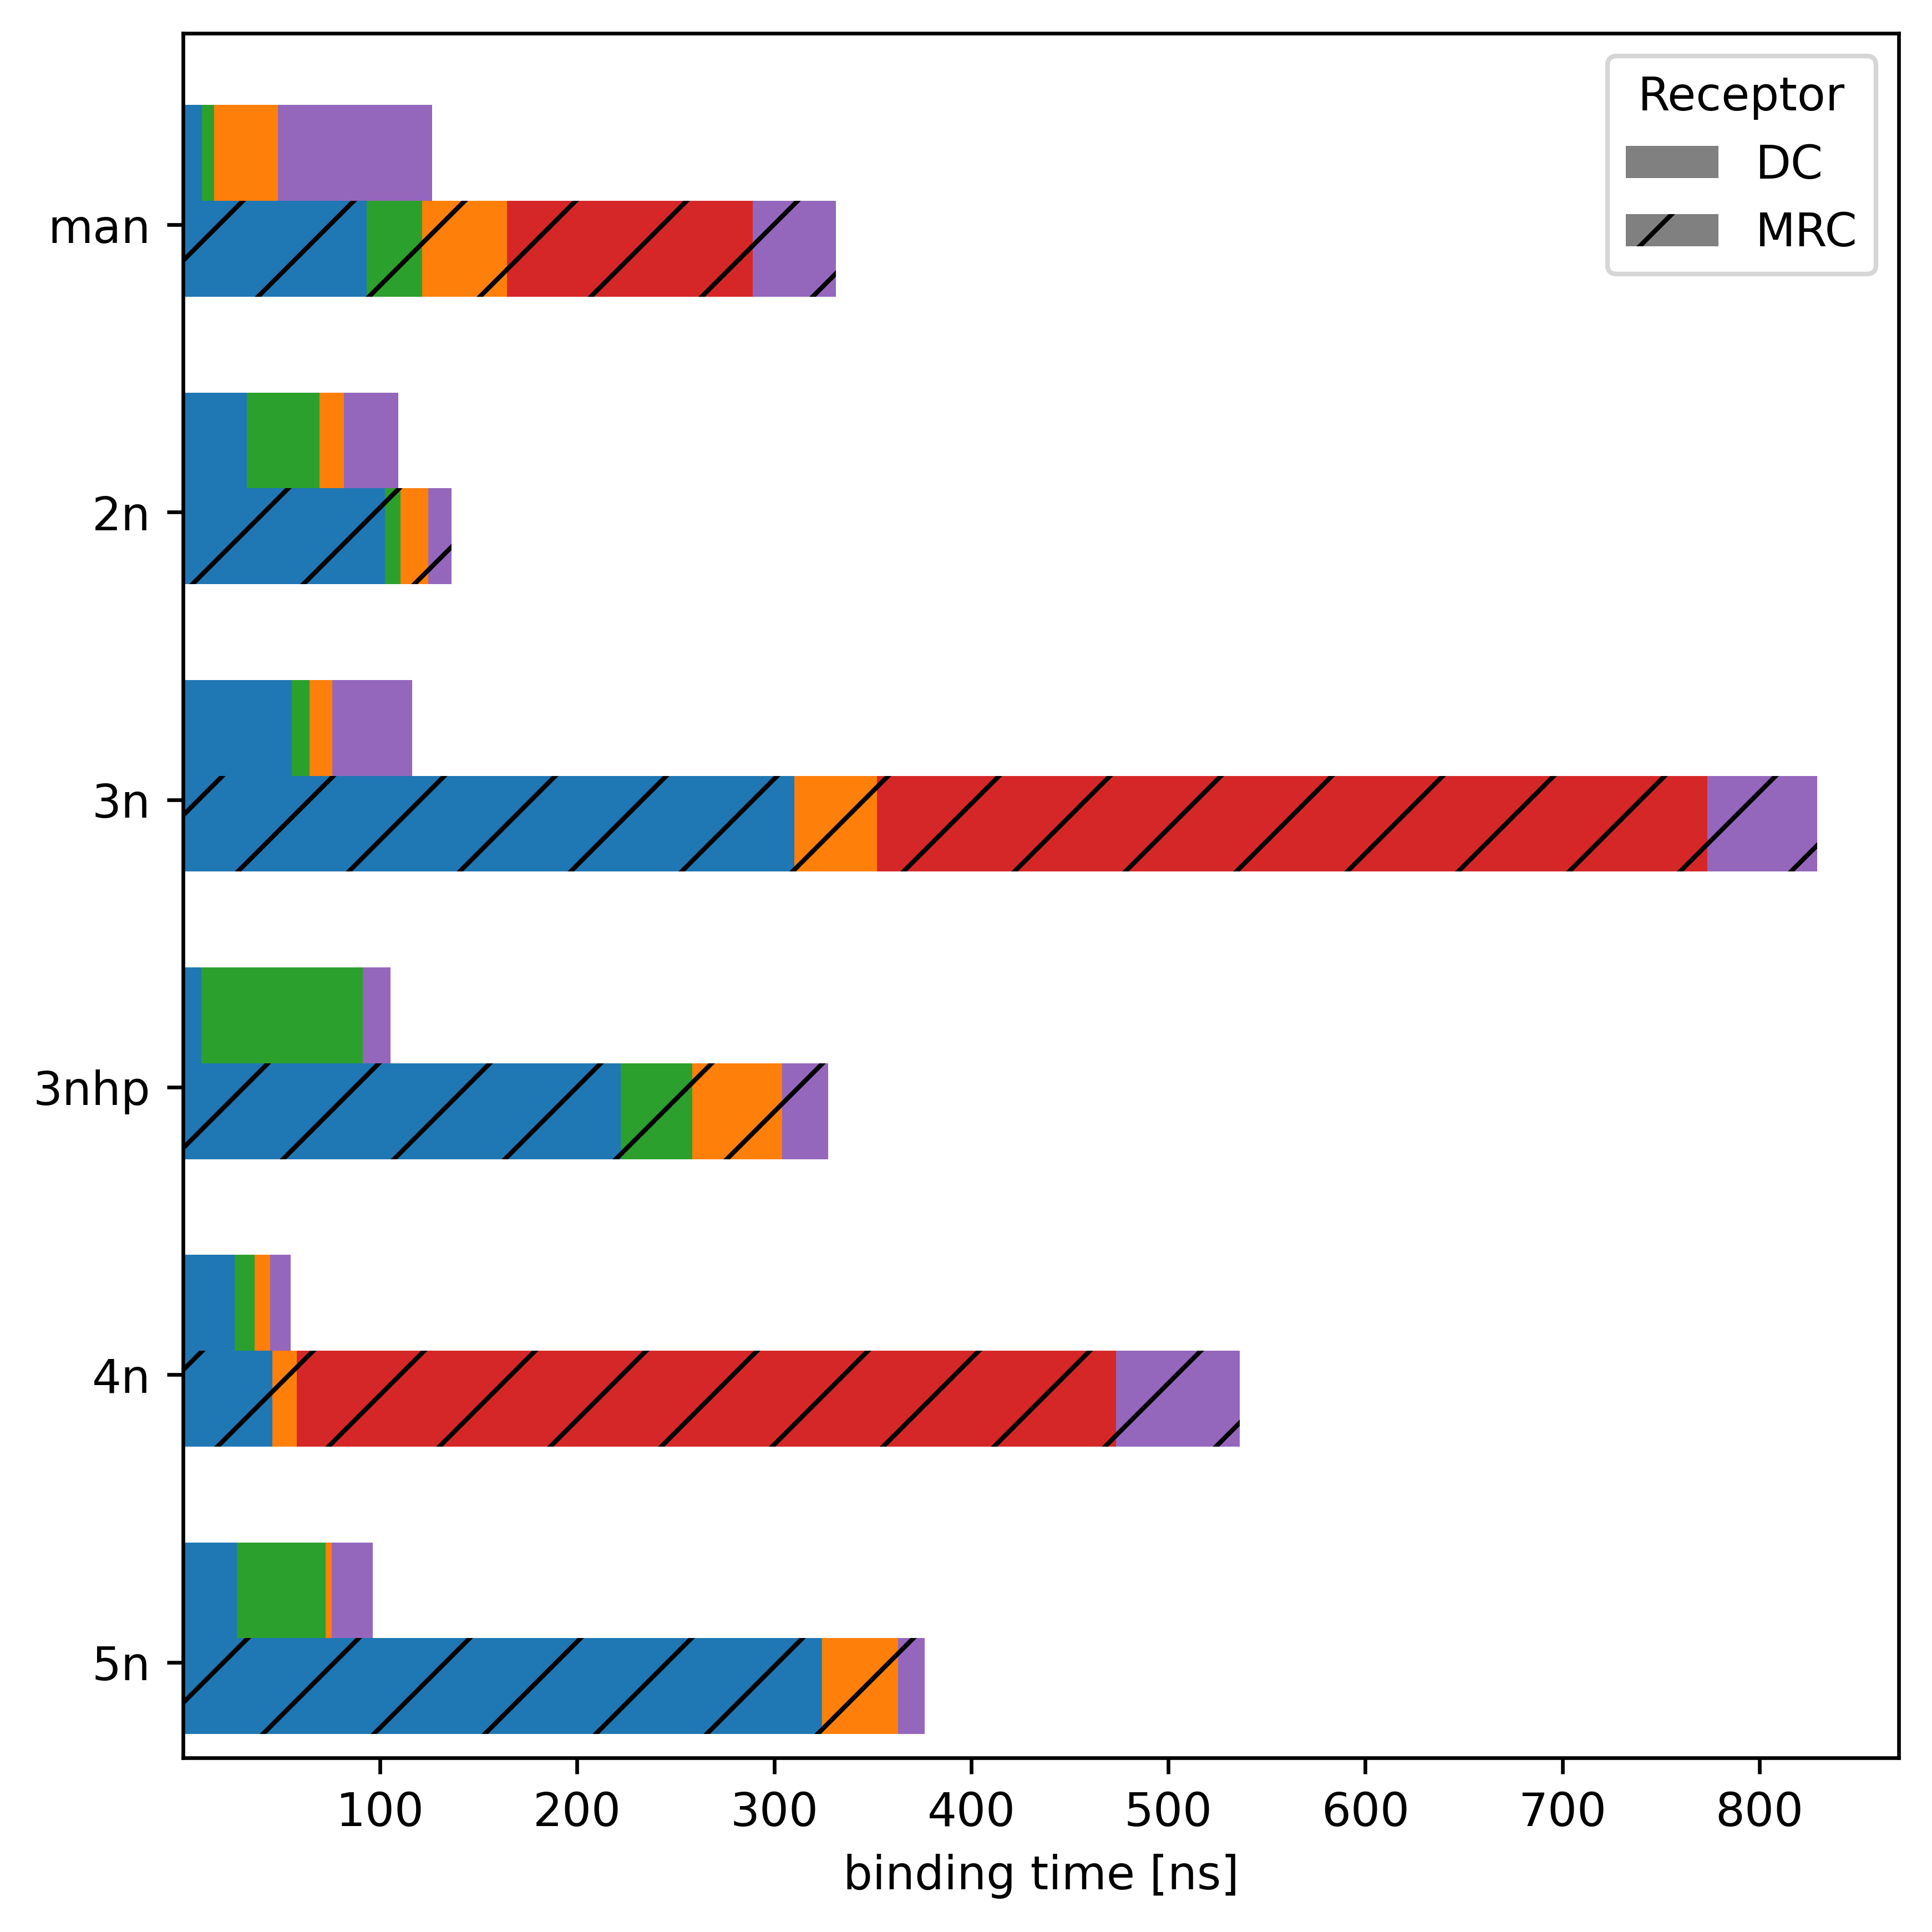

In [53]:
# plot
cm = 1/2.54
fig, ax = plt.subplots(figsize=(15*cm, 15*cm), dpi=600)
plot_clustered_stacked_horizontal([dc,mrc],["MRC","DC"])
plt.xlabel('binding time [ns]')
# plt.ylabel('ligand')
plt.xticks([1000, 2000, 3000, 4000, 5000, 6000, 7000, 8000], ['100', '200', '300', '400', '500', '600', '700', '800'], fontsize=10)
plt.tight_layout()
# plt.savefig('/data/geissler/analysis/states_stacked_barplot_review.png')

## Figure 7b) mmPBSA binding affinities for each state

mmPBSA affinities were calculated with the gmx_MMPBSA Tool (by Valdes-Tresanco *et al.*), see the mmPBSA bash script for more details. 
<br>
In this figure only mmPBSA values calculated on at least 100 frames of simulation and with an error bar of less than 1 are plotted.

In [12]:
# create dataframe
# structure: [ligand (0-5), receptor (0/1), state (specific color), mmPBSA-value]

mmpbsa=pd.DataFrame([[0,1,'#d62728',-25.37], # man-mrc-C (300 frames, error 0.27)
    [2, 1, '#d62728', -30.14],  # 3n-mrc-C (300 frames, error 0.29)
    [4, 1, '#d62728', -27.86],  # 4n-mrc-C (300 frames, error 0.43!!!)
                     
    [0, 0, '#ff7f0e', -11.41],  # man-dc-B (318 frames, error 0.17)
    [1, 0, '#ff7f0e', -14.99],  # 2n-dc-B (110 frames, error 0.47)
    [2, 0, '#ff7f0e', -14.36,],  # 3n-dc-B (101 frames, error 0.39)
                     
    [0, 1, '#ff7f0e', -18.83],  # man-mrc-B (286 frames, error 0.23)
    [1, 1, '#ff7f0e', -22.63],  # 2n-mrc-B (141 frames, error 0.46)
    [2, 1, '#ff7f0e', -24.50,],  # 3n-mrc-B (273 frames, error 0.34)
    [3, 1, '#ff7f0e', -26.02,],  # 3n-hp-mrc-B (300 frames, error 0.32)
    [4, 1, '#ff7f0e', -27.05,],  # 4n-mrc-B (110 frames, error 0.88!!!)
    [5, 1, '#ff7f0e', -22.90,],  # 5n-mrc-B (295 frames, error 0.42)
                     
    [1, 0, '#1f77b4', -15.25],  # 2n-dc-crystal (209 frames, error 0.29)
    [2, 0, '#1f77b4', -13.91],  # 3n-dc-crystal (300 frames, error 0.28)
    [4, 0, '#1f77b4', -13.62],  # 4n-dc-crystal (261 frames, error 0.36)
    [5, 0, '#1f77b4', -15.11,],  # 5n-dc-crystal (223 frames, error 0.34)
                     
    [0, 1, '#1f77b4', -21.47],  # man-mrc-crystal (300 frames, error 0.23)
    [1, 1, '#1f77b4', -25.08],  # 2n-mrc-crystal (300 frames, error 0.24)
    [2, 1, '#1f77b4', -26.43,],  # 3n-mrc-crystal (300 frames, error 0.24)
    [3, 1, '#1f77b4', -27.44,],  # 3nhp-mrc-crystal (301 frames, error 0.26)
    [4, 1, '#1f77b4', -25.14],  # 4n-mrc-crystal (337 frames, error 0.27)
    [5, 1, '#1f77b4', -26.43],  # 5n-mrc-crystal (400 frames, error 0.23)
                     
    [1, 0, '#2ca02c', -14.03],  # 2n-dc-A (369 frames, error 0.10)
    [3, 0, '#2ca02c', -14.76],  # 3nhp-dc-A (300 frames, error 0.30)
    [4, 0, '#2ca02c', -9.85],  # 4n-dc-A (103 frames, error 0.42)                 
    [5, 0, '#2ca02c', -19.12,],  # 5n-dc-A (300 frames, error 0.29)
                     
    [0, 1, '#2ca02c', -24.87],  # man-mrc-A (281 frames, error 0.26)
    [3, 1, '#2ca02c', -27.47],  # 3nhp-mrc-A (344 frames, error 0.37)
                     
                    ],
               # index=["man", "2n", "3n", "3nhp","4n","5n"],
               #     columns=["crystal", "A", "B", "C", "other"]
               )  

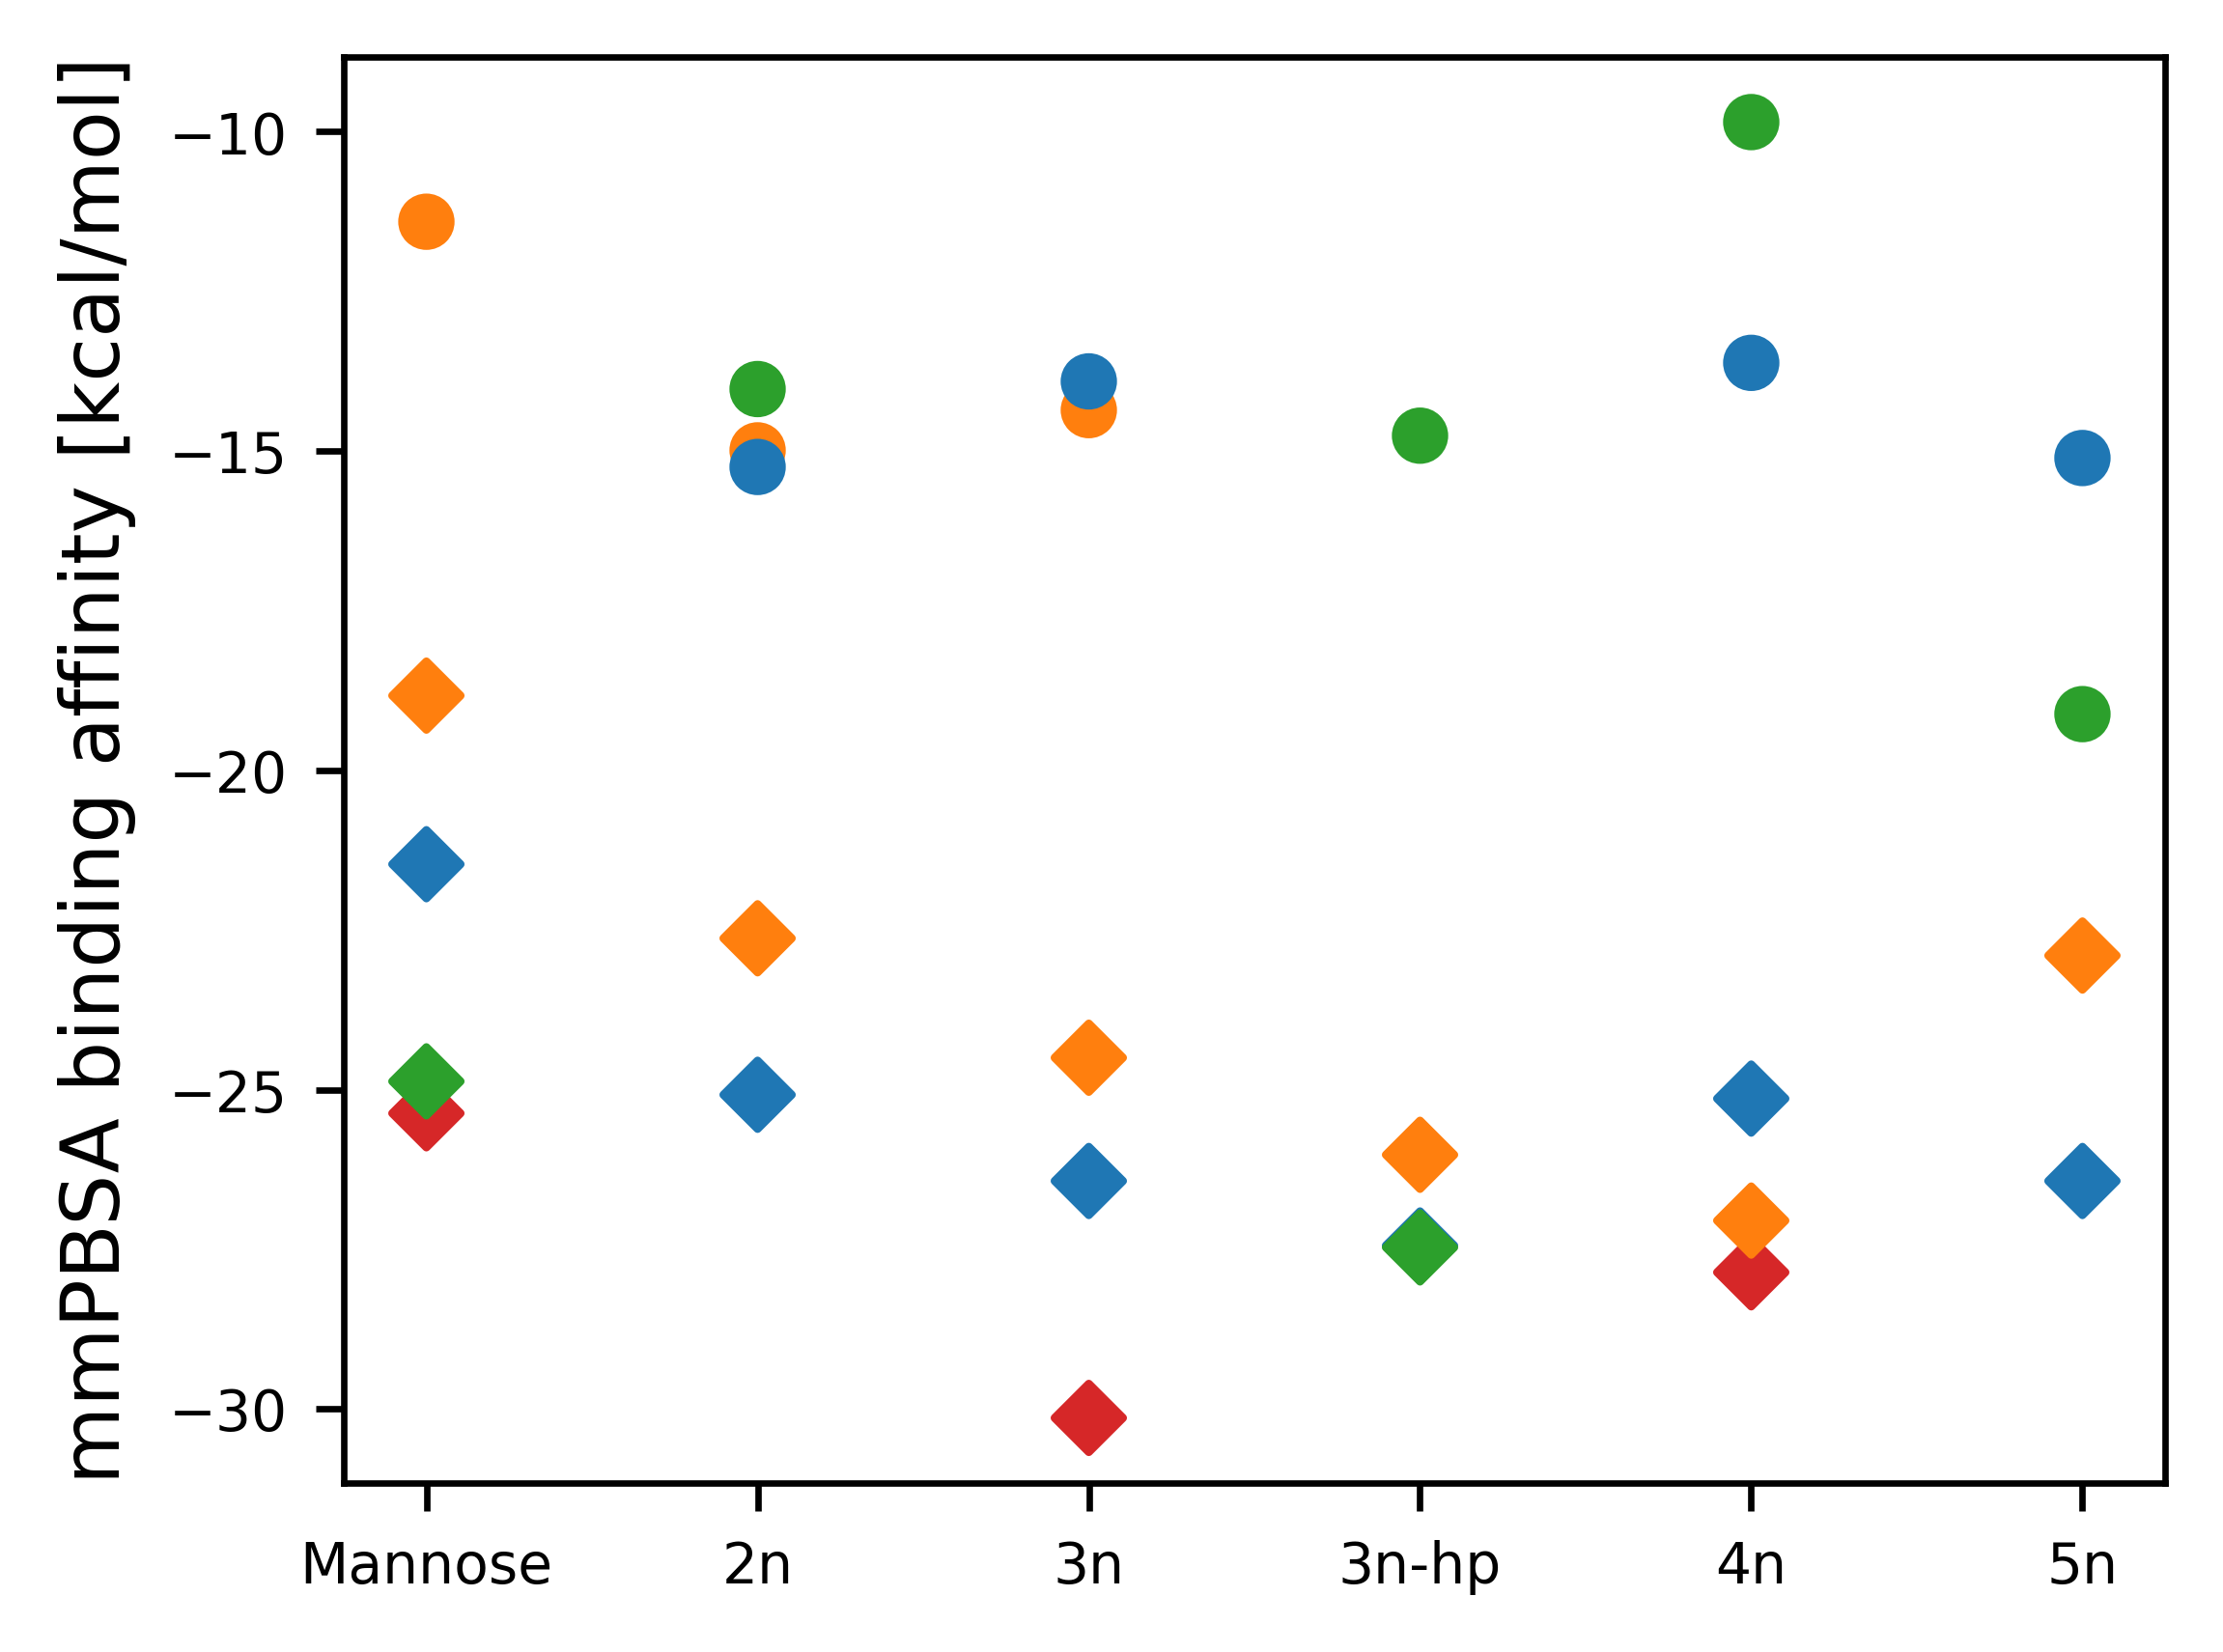

In [19]:
cm = 1/2.54
# Map second column to two marker styles
marker_map = {
    mmpbsa.iloc[:, 1].unique()[0]: 'D',   # circle
    mmpbsa.iloc[:, 1].unique()[1]: 'o'    # square
}

fig, ax = plt.subplots(figsize=(10*cm, 7.5*cm), dpi=600)
# Loop over the two marker groups
for marker_value, group in mmpbsa.groupby(mmpbsa.columns[1]):
    plt.scatter(
        group.iloc[:, 0],        # x
        group.iloc[:, 3],        # y
        c=group.iloc[:, 2],      # colors (Matplotlib default colormap)
        marker=marker_map[marker_value],
        # s=1,
        # alpha = 0.5,
        label=str(marker_value),
    )

plt.xticks([0, 1, 2, 3, 4, 5], ['Mannose', '2n', '3n', '3n-hp', '4n', '5n'], fontsize=7)
plt.yticks(fontsize=7)
plt.ylabel('mmPBSA binding affinity [kcal/mol]')
plt.tight_layout()
# plt.savefig('/data/geissler/analysis/mmpbsa_graph.png')
plt.show()